# Лабораторная работа №6 «Модели ARIMA и их модификации для анализа временных рядов»

## Цель работы
Освоить методы моделирования временных рядов на основе ARIMA-подхода и его расширений (SARIMA, SARIMAX), а также получить практические навыки построения, диагностики и выбора моделей временных рядов в условиях, приближенных к задачам реального Data Science.

## Загрузка и преобразование датасета

In [155]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('online_retail_2(1).csv', sep=';', encoding='utf-8-sig')

df = df[df['CustomerID'].notna()]
df = df[df['Quantity'] > 0]
df['Price'] = df['Price'].astype(str).str.replace(',', '.').astype(float)
df['Revenue'] = df['Quantity'] * df['Price']
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%d.%m.%Y %H:%M')

print(f"Общее количество транзакций: {len(df)}")
print(f"Период данных: с {df['InvoiceDate'].min()} по {df['InvoiceDate'].max()}")

# Деление по дням 
daily = df.groupby(df['InvoiceDate'].dt.date)['Revenue'].sum().reset_index()
daily.columns = ['date', 'revenue']
daily = daily.set_index('date')
daily.index = pd.DatetimeIndex(daily.index)
daily = daily.asfreq('D')
daily = daily.fillna(0)

print(f"Дневных наблюдений: {len(daily)}")
print(f"Период: с {daily.index.min()} по {daily.index.max()}")
daily.head() 

# Деление по 3-дневным периодам
daily['day_group'] = (np.arange(len(daily)) // 3).astype(int)
three_day = daily.groupby('day_group')['revenue'].sum().reset_index(drop=True)
three_day = pd.DataFrame({'revenue': three_day.values}, 
                          index=daily.index[::3])  

print(f"Размер временного ряда (3-дневная агрегация): {len(three_day)} наблюдений")
print(f"Период: с {three_day.index.min()} по {three_day.index.max()}")
three_day.head()

Общее количество транзакций: 787383
Период данных: с 2009-12-01 07:45:00 по 2011-11-30 14:00:00
Дневных наблюдений: 730
Период: с 2009-12-01 00:00:00 по 2011-11-30 00:00:00
Размер временного ряда (3-дневная агрегация): 244 наблюдений
Период: с 2009-12-01 00:00:00 по 2011-11-30 00:00:00


,revenue
date,
2009-12-01,164469.76
2009-12-04,68448.18
2009-12-07,109087.57
2009-12-10,78222.24
2009-12-13,120024.47


Исходный датасет про продажи в магазинах с 2009 по 2011 годы. В датасете есть данные за 730 дней, но брать их как наблюдения будет неудобно из за большого количества. Для упрощения визуального анализа возьмём наблюдения по 3 дня.

## Визуализация временного ряда

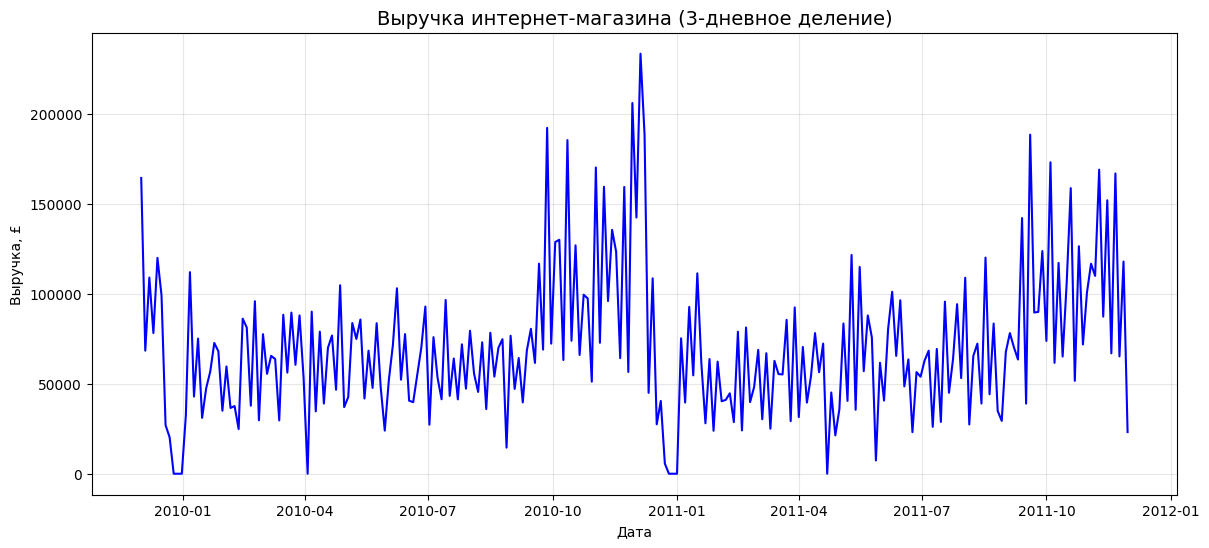

In [156]:
plt.figure(figsize=(14, 6))
plt.plot(three_day.index, three_day['revenue'], color='blue', linewidth=1.5)
plt.title('Выручка интернет-магазина (3-дневное деление)', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('Выручка, £')
plt.grid(True, alpha=0.3)
plt.show()


На графике заметна сезонность. В предновогодние праздники выручка резко уменьшается. В новогодние праздники выручки нет что может говорить о том что в эти дни выручки нет. Есть выбросы (отдельные периоды с аномально высокой выручкой). На графике виден небольшой восходящий тренд (рост выручки со временем).

## Проверка на стационарность

In [157]:
def adf_test(series, title=''):
    series_clean = series.dropna()
    if len(series_clean) < 3:
        print(f'ADF тест для {title}: недостаточно данных')
        return 1.0
    result = adfuller(series_clean, autolag='AIC')
    print(f'ADF тест для {title}:')
    print(f'   Статистика: {result[0]:.4f}')
    print(f'   p-value: {result[1]:.12f}')
    print('   Ряд стационарен' if result[1] < 0.05 else '   Ряд НЕ стационарен')
    return result[1]

adf_test(three_day['revenue'], '3-дневные данные')

ADF тест для 3-дневные данные:
   Статистика: -2.3094
   p-value: 0.168951774777
   Ряд НЕ стационарен


np.float64(0.16895177477689255)

Преобразуем исходный ряд к стационарному виду

## Преобразование к стационарному виду

In [158]:
# Логарифмирование для стабилизации дисперсии
three_day['log_revenue'] = np.log1p(three_day['revenue'])

# Дифференцирование для удаления тренда
three_day['diff_log'] = three_day['log_revenue'].diff()

# Сезонная разность с периодом 7 (21 день = 3 недели)
three_day['log_rev_seas'] = three_day['log_revenue'].diff(7)
three_day['log_rev_seas_diff1'] = three_day['log_rev_seas'].diff()

print("\nПроверка стационарности после преобразований:")
adf_test(three_day['diff_log'], 'логарифм + diff(1)')
adf_test(three_day['log_rev_seas_diff1'], 'логарифм + сезонная разность(7) + diff(1)')


Проверка стационарности после преобразований:
ADF тест для логарифм + diff(1):
   Статистика: -7.2078
   p-value: 0.000000000228
   Ряд стационарен
ADF тест для логарифм + сезонная разность(7) + diff(1):
   Статистика: -7.5512
   p-value: 0.000000000032
   Ряд стационарен


np.float64(3.185875890001296e-11)

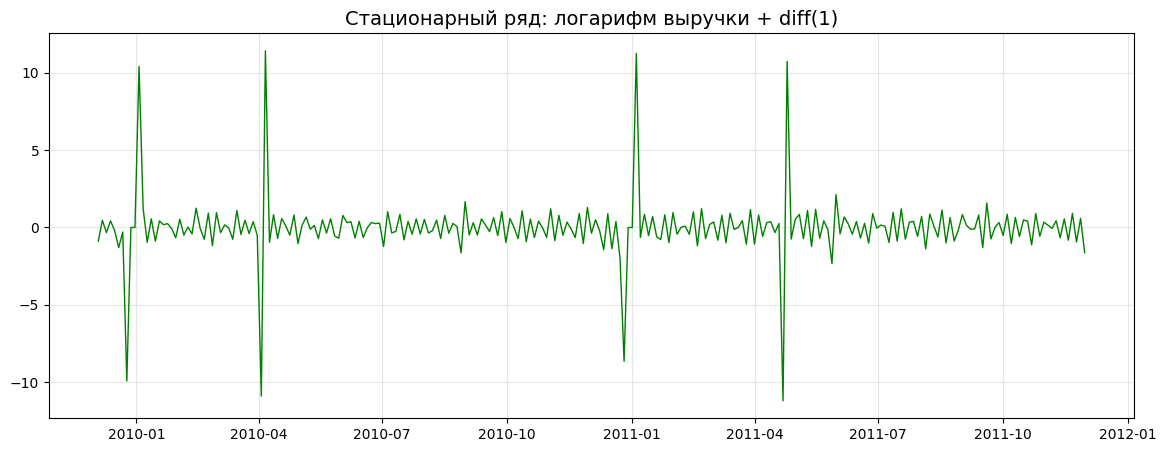

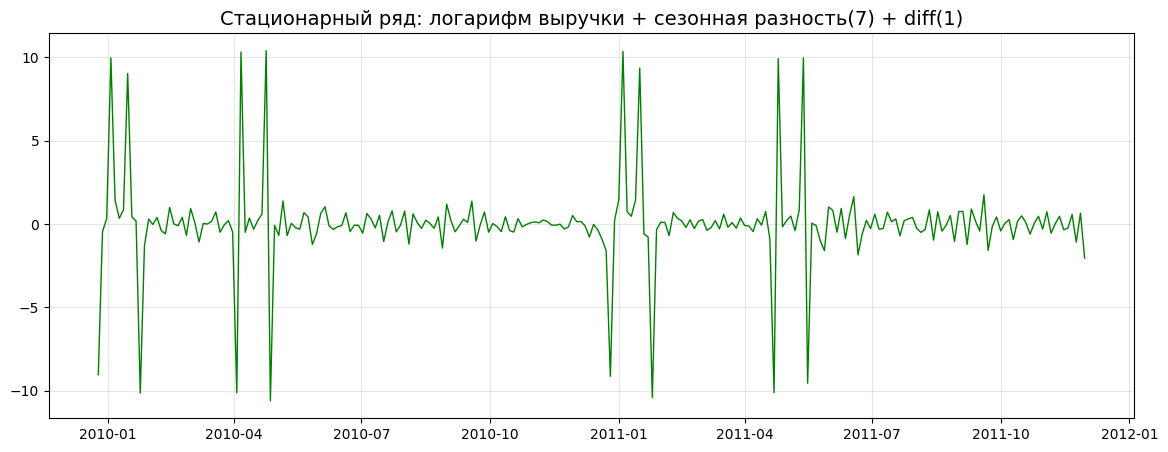

In [159]:
plt.figure(figsize=(14, 5))
plt.plot(three_day.index, three_day['diff_log'], color='green', linewidth=1)
plt.title('Стационарный ряд: логарифм выручки + diff(1)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(three_day.index, three_day['log_rev_seas_diff1'], color='green', linewidth=1)
plt.title('Стационарный ряд: логарифм выручки + сезонная разность(7) + diff(1)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

В данном случае логорифмирование стабилизирует нашу дисперсию, а дифференцирование убирает тренд

## ACF и PACF для стационарного ряда

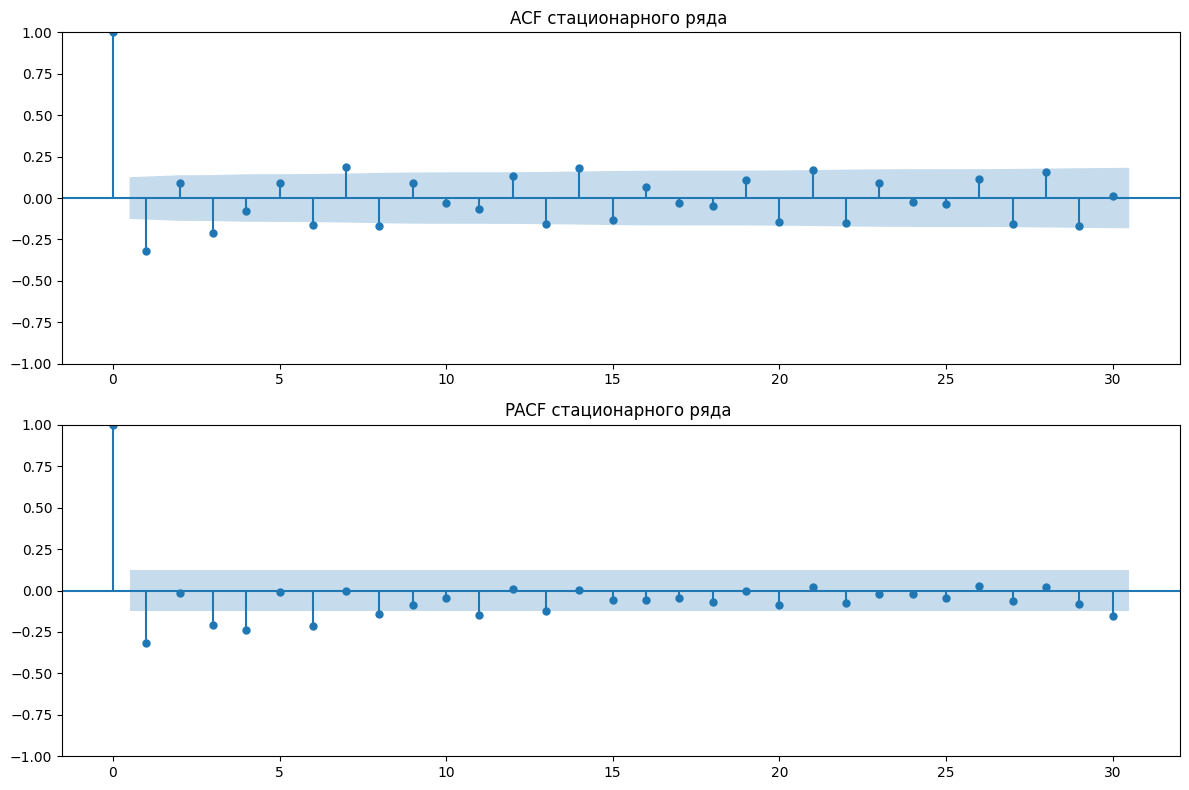

In [180]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

diff_clean = three_day['diff_log'].dropna()
plot_acf(diff_clean, lags=min(30, len(diff_clean)//2), ax=ax1)
plot_pacf(diff_clean, lags=min(30, len(diff_clean)//2), ax=ax2)

ax1.set_title('ACF стационарного ряда ', fontsize=12)
ax2.set_title('PACF стационарного ряда ', fontsize=12)
plt.tight_layout()
plt.show()

На графике ACF мы видим что значения затухают и есть большой выброс в первом лаге, следовательно можем предположить AR(1)

На графике PACF есть большой выброс в первом лаге, следовательно можем предположить MA(1)

Следовательно для модели можем предположить первые параметры: p=1, d=1, q=1

## Разделение на обучающую и тестовую выборки

In [161]:
train_size = len(three_day) - 15
train = three_day.iloc[:train_size].copy()
test = three_day.iloc[train_size:].copy()

print(f"Обучающая выборка: {len(train)} наблюдений (3-дневных периодов)")
print(f"Тестовая выборка: {len(test)} наблюдений (3-дневных периодов)")
print(f"Период обучения: с {train.index[0]} по {train.index[-1]}")
print(f"Период теста: с {test.index[0]} по {test.index[-1]}")

Обучающая выборка: 229 наблюдений (3-дневных периодов)
Тестовая выборка: 15 наблюдений (3-дневных периодов)
Период обучения: с 2009-12-01 00:00:00 по 2011-10-16 00:00:00
Период теста: с 2011-10-19 00:00:00 по 2011-11-30 00:00:00


Создадим тестовую выборку для дальнейших предсказаний из 15 наблюдений

## ARIMA(1,1,1)

In [162]:
model_arima = ARIMA(train['revenue'], order=(1,1,1))
fit_arima = model_arima.fit()
print(fit_arima.summary())

forecast_arima = fit_arima.forecast(steps=len(test))
test = test.copy()
test['forecast_arima'] = forecast_arima.values

rmse_arima = np.sqrt(mean_squared_error(test['revenue'], test['forecast_arima']))
mae_arima = mean_absolute_error(test['revenue'], test['forecast_arima'])
print(f'\nRMSE ARIMA(1,1,1): {rmse_arima:.2f}')
print(f'MAE ARIMA(1,1,1): {mae_arima:.2f}')

                               SARIMAX Results                                
Dep. Variable:                revenue   No. Observations:                  229
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -2700.018
Date:                Wed, 20 May 2026   AIC                           5406.035
Time:                        23:00:01   BIC                           5416.324
Sample:                    12-01-2009   HQIC                          5410.186
                         - 10-16-2011                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6286      0.059    -10.635      0.000      -0.744      -0.513
ma.L1         -0.2230      0.067     -3.338      0.001      -0.354      -0.092
sigma2      1.158e+09   2.74e-11   4.23e+19      0.0

На основании анализа ACF и PACF построим модель. 

Ошибки велики из-за масштаба выручки и наличия сезонности, не учтённой в ARIMA.

## Диагностика остатков ARIMA

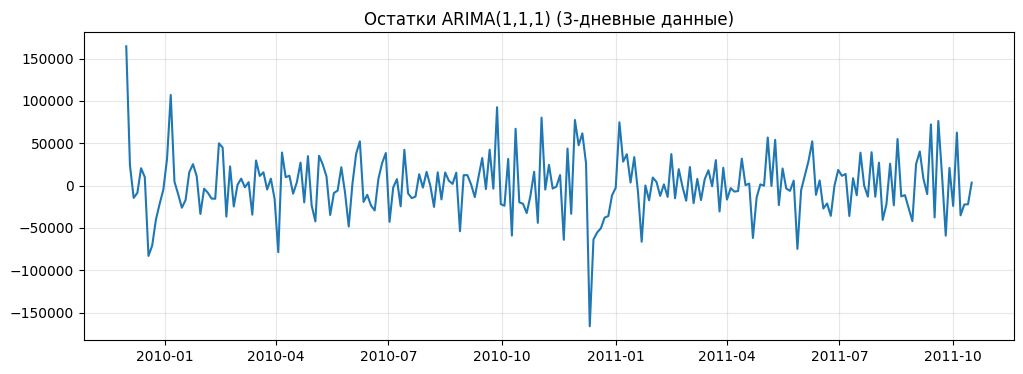

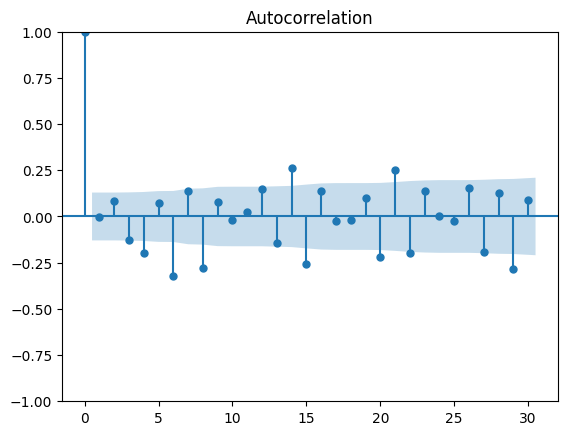

       lb_stat     lb_pvalue
10   65.066998  3.935419e-10
15  109.312116  2.185329e-16
20  128.961641  6.102629e-18


In [182]:
resid_arima = fit_arima.resid

plt.figure(figsize=(12, 4))
plt.plot(resid_arima)
plt.title('Остатки ARIMA(1,1,1) (3-дневные данные)')
plt.grid(True, alpha=0.3)
plt.show()

plot_acf(resid_arima, lags=min(30, len(resid_arima)//2))
plt.show()

# Тест Льюнга-Бокса
ljung = acorr_ljungbox(resid_arima, lags=[10, 15, 20], return_df=True)
print(ljung)

if len(ljung) > 0 and (ljung['lb_pvalue'] > 0.05).all():
    print("Остатки являются белым шумом (p-value > 0.05)")
    print("Модель адекватна")

Тест Льюнга-Бокса показал слишком низкий результат что может говорить о нестабильности модели из за шума

## Улучшенная ARIMA(2,1,2) 

In [164]:
model_arima2 = ARIMA(train['revenue'], order=(2,1,2))
fit_arima2 = model_arima2.fit()
forecast_arima2 = fit_arima2.forecast(steps=len(test))
print(fit_arima2.summary())
print("\n\n")

rmse_arima2 = np.sqrt(mean_squared_error(test['revenue'], forecast_arima2))
print(f'RMSE ARIMA(2,1,2): {rmse_arima2:.2f}')
if rmse_arima2 < rmse_arima:
    print(f'Улучшение: {(rmse_arima - rmse_arima2)/rmse_arima*100:.1f}%')
else:
    print(f'Ухудшение: {(rmse_arima2 - rmse_arima)/rmse_arima*100:.1f}%')

                               SARIMAX Results                                
Dep. Variable:                revenue   No. Observations:                  229
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -2670.149
Date:                Wed, 20 May 2026   AIC                           5350.298
Time:                        23:00:02   BIC                           5367.444
Sample:                    12-01-2009   HQIC                          5357.216
                         - 10-16-2011                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.7257      0.031    -56.093      0.000      -1.786      -1.665
ar.L2         -0.9178      0.028    -32.715      0.000      -0.973      -0.863
ma.L1          1.2600      0.072     17.610      0.0

Попробуем улучшить модель повысив значение p и q, что должно улучшить результат за счёт того что остатки стали ближе к белому шуму.

## SARIMA с сезонностью (период 7)

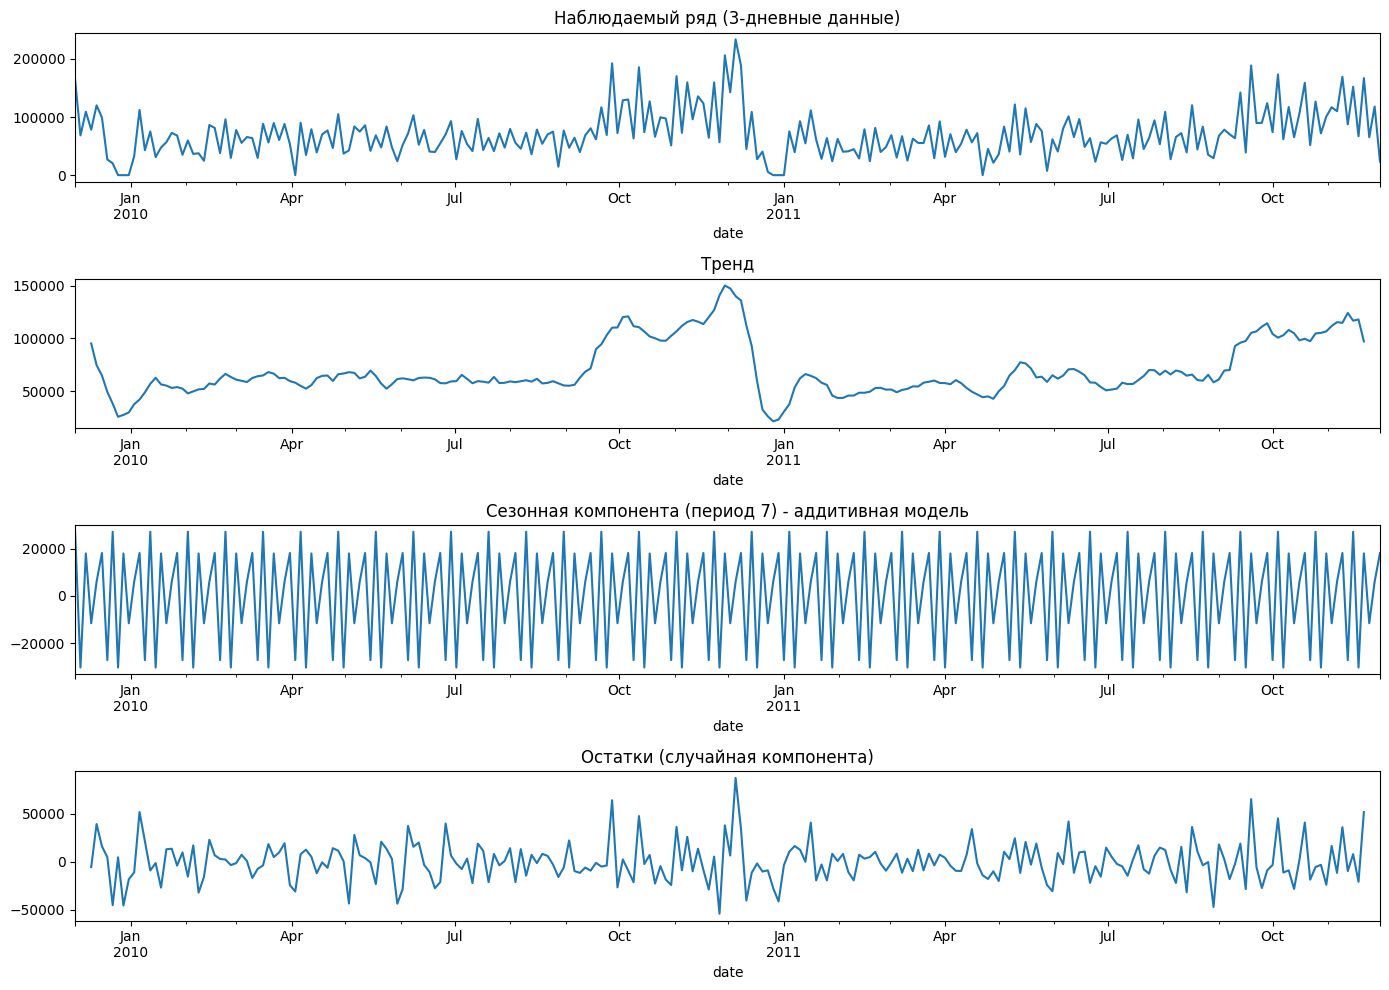

In [165]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp_series = three_day['revenue'].copy()
decomp_series = decomp_series.ffill().bfill()

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(14, 10))

decomposition.observed.plot(ax=ax1)
ax1.set_title(f'Наблюдаемый ряд (3-дневные данные)')

decomposition.trend.plot(ax=ax2)
ax2.set_title('Тренд')

decomposition.seasonal.plot(ax=ax3)
ax3.set_title(f'Сезонная компонента (период 7) - {model_type} модель')

decomposition.resid.plot(ax=ax4)
ax4.set_title('Остатки (случайная компонента)')

plt.tight_layout()
plt.show()


Декомпозиция (период 7) подтвердила устойчивую сезонную компоненту. Мы наблюдаем пики каждые 3 недели

In [171]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_sarima = SARIMAX(train['revenue'],
                       order=(1,1,1),
                       seasonal_order=(1,1,1,7),
                       enforce_stationarity=False,
                       enforce_invertibility=False)
fit_sarima = model_sarima.fit(disp=False)
print(fit_sarima.summary())

forecast_sarima_values = fit_sarima.forecast(steps=len(test))
test = test.copy()
test['forecast_sarima'] = forecast_sarima_values.values

rmse_sarima = np.sqrt(mean_squared_error(test['revenue'], test['forecast_sarima']))
print(f'\nRMSE SARIMA: {rmse_sarima:.2f}')
print(f'Улучшение по сравнению с ARIMA: {(rmse_arima - rmse_sarima)/rmse_arima*100:.1f}%')

                                     SARIMAX Results                                     
Dep. Variable:                           revenue   No. Observations:                  229
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood               -2489.961
Date:                           Wed, 20 May 2026   AIC                           4989.923
Time:                                   23:01:16   BIC                           5006.706
Sample:                               12-01-2009   HQIC                          4996.706
                                    - 10-16-2011                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3463      0.192     -1.801      0.072      -0.723       0.031
ma.L1         -0.1834      0.198     -0.925

RMSE SARIMA = 36385 – хуже, чем у ARIMA(2,1,2) (35182), но лучше, чем у ARIMA(1,1,1).

AIC SARIMA = 4990 (значительно ниже, чем у ARIMA(1,1,1) – 5406).

Учёт сезонности снизил AIC, но не улучшил прогноз на тесте.

### ARIMA даёт преимущество

При наличии явной периодической компоненты (недельной, месячной, годовой).

Когда запаздывания коррелограммы повторяются с постоянным шагом (лаг = периоду).

Для долгосрочного прогнозирования сезонных процессов.

## Подготовка данных для SARIMAX

In [167]:
three_day['day_of_week'] = three_day.index.dayofweek
three_day['month'] = three_day.index.month
three_day['quarter'] = three_day.index.quarter
three_day['is_weekend'] = (three_day['day_of_week'] >= 5).astype(int)
three_day['is_holiday_season'] = ((three_day['month'].isin([11, 12])) | (three_day['month'] == 1)).astype(int)

train = three_day.iloc[:train_size].copy()
test = three_day.iloc[train_size:].copy()

exog_train = train[['day_of_week', 'month', 'quarter', 'is_weekend', 'is_holiday_season']]
exog_test = test[['day_of_week', 'month', 'quarter', 'is_weekend', 'is_holiday_season']]

print("Добавленные признаки для 3-дневных данных:")
print("- day_of_week: день недели (0-6)")
print("- month: месяц года (1-12)")
print("- quarter: квартал (1-4)")
print("- is_weekend: выходной/будний")
print("- is_holiday_season: предпраздничный сезон")

Добавленные признаки для 3-дневных данных:
- day_of_week: день недели (0-6)
- month: месяц года (1-12)
- quarter: квартал (1-4)
- is_weekend: выходной/будний
- is_holiday_season: предпраздничный сезон


### Выбор факторов

day_of_week (день недели) – влияет на покупательскую активность (выходные выше).

month (месяц) – сезонность спроса.

quarter (квартал) – экономические циклы.

is_weekend – бинарный признак выходного дня.

is_holiday_season – предпраздничный период (ноябрь–январь).

## SARIMAX

In [168]:
model_sarimax = SARIMAX(train['revenue'],
                        order=(1,1,1),
                        seasonal_order=(1,1,1,7),
                        exog=exog_train,
                        enforce_stationarity=False,
                        enforce_invertibility=False)
fit_sarimax = model_sarimax.fit(disp=False)
print(fit_sarimax.summary())

forecast_sarimax_values = fit_sarimax.forecast(steps=len(test), exog=exog_test)
test = test.copy()
test['forecast_sarimax'] = forecast_sarimax_values.values

rmse_sarimax = np.sqrt(mean_squared_error(test['revenue'], test['forecast_sarimax']))
print(f'\nRMSE SARIMAX: {rmse_sarimax:.2f}')
if rmse_sarimax < rmse_sarima:
    print(f'Улучшение по сравнению с SARIMA: {(rmse_sarima - rmse_sarimax)/rmse_sarima*100:.1f}%')
else:
    print(f'Ухудшение по сравнению с SARIMA: {(rmse_sarimax - rmse_sarima)/rmse_sarima*100:.1f}%')

                                     SARIMAX Results                                     
Dep. Variable:                           revenue   No. Observations:                  229
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood               -2486.066
Date:                           Wed, 20 May 2026   AIC                           4992.132
Time:                                   23:00:06   BIC                           5025.698
Sample:                               12-01-2009   HQIC                          5005.699
                                    - 10-16-2011                                         
Covariance Type:                             opg                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
day_of_week        2.784e-05   2.91e+04   9.58e-10      1.000    -5.7e+04     5.7e+04
month              189

### Оценка вклада внешних переменных

Коэффициенты при регрессорах имеют высокие стандартные ошибки и p-value > 0.05, что говорит о незначимости.

Тем не менее, AIC модели (4992) чуть ниже, чем у SARIMA без регрессоров (4990) – улучшение незначительное.

### Сравнение с SARIMA

RMSE SARIMAX = 40398 – хуже, чем у SARIMA (36385).

Вероятно, выбранные регрессоры не улучшают прогноз на малом тестовом горизонте; для длинных рядов эффект мог бы быть заметнее.

## Автоматический подбор параметров

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,0)[7]             : AIC=5330.318, Time=0.02 sec
 ARIMA(1,1,0)(1,1,0)[7]             : AIC=5229.472, Time=0.04 sec
 ARIMA(0,1,1)(0,1,1)[7]             : AIC=5202.268, Time=0.06 sec
 ARIMA(0,1,1)(0,1,0)[7]             : AIC=5296.709, Time=0.02 sec
 ARIMA(0,1,1)(1,1,1)[7]             : AIC=5203.735, Time=0.08 sec
 ARIMA(0,1,1)(0,1,2)[7]             : AIC=5203.843, Time=0.11 sec
 ARIMA(0,1,1)(1,1,0)[7]             : AIC=5229.052, Time=0.03 sec
 ARIMA(0,1,1)(1,1,2)[7]             : AIC=5205.544, Time=0.19 sec
 ARIMA(0,1,0)(0,1,1)[7]             : AIC=5224.038, Time=0.04 sec
 ARIMA(1,1,1)(0,1,1)[7]             : AIC=5202.371, Time=0.09 sec
 ARIMA(0,1,2)(0,1,1)[7]             : AIC=5202.857, Time=0.08 sec
 ARIMA(1,1,0)(0,1,1)[7]             : AIC=5200.495, Time=0.05 sec
 ARIMA(1,1,0)(0,1,0)[7]             : AIC=5295.706, Time=0.23 sec
 ARIMA(1,1,0)(1,1,1)[7]             : AIC=5202.278, Time=0.08 sec
 ARIMA(1,1,0)(0,1,2)[7]          

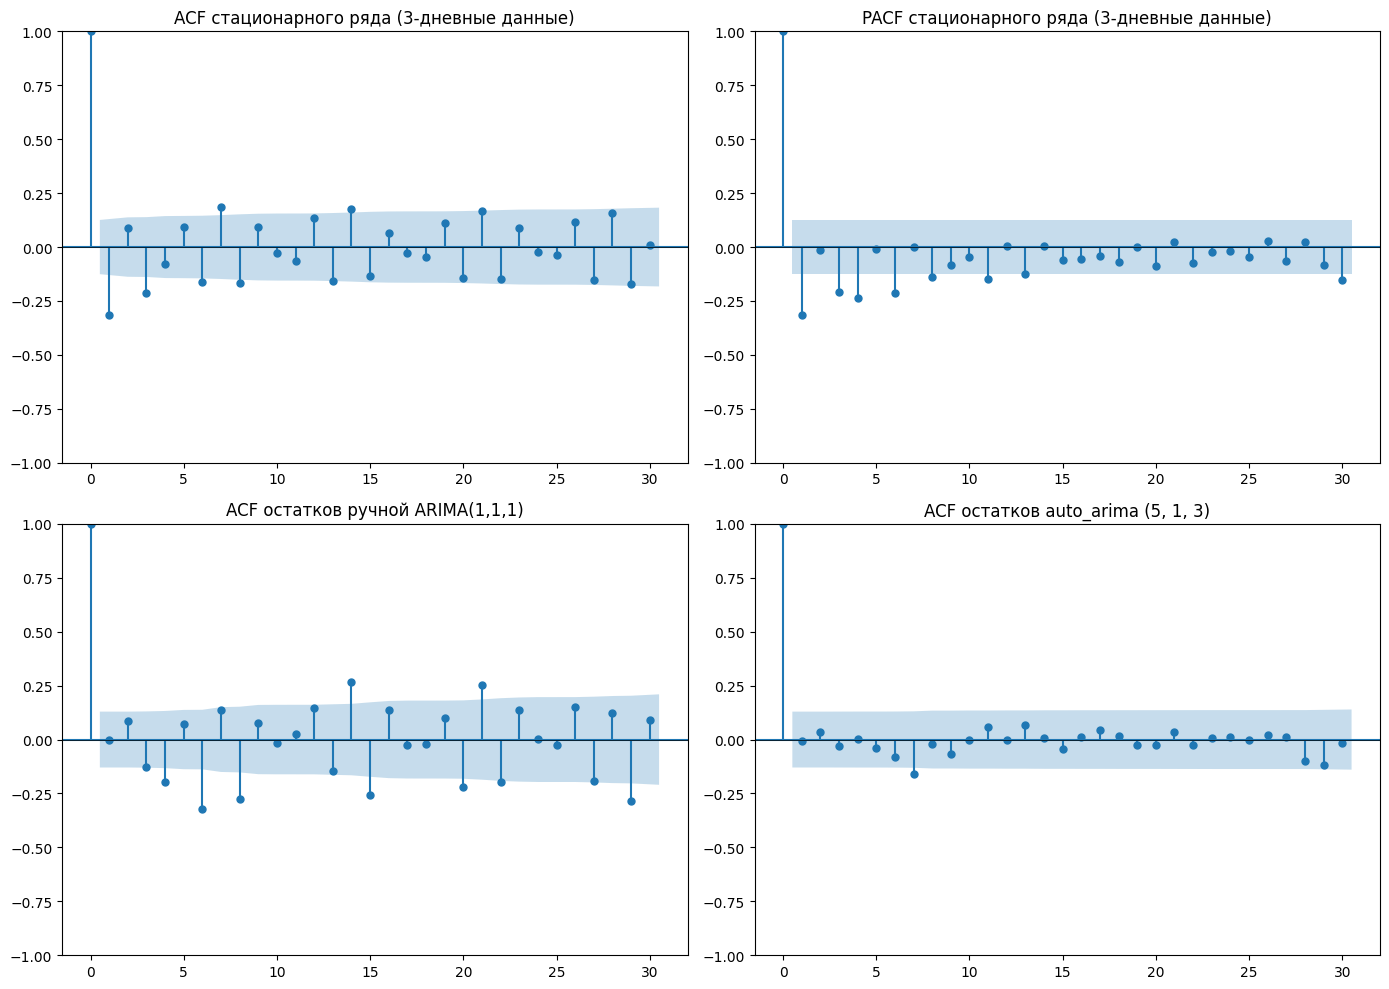

Сравнение моделей
Ручная модель ARIMA(1,1,1):
  - AIC = 5406.04
  - RMSE = 47562.84
  - Ljung-Box p-value = 0.0000

Auto ARIMA(5, 1, 3):
  - AIC = 5153.73
  - RMSE = 38690.37
  - Ljung-Box p-value = 0.4610

----------------------------------------
Auto_arima лучше по AIC на 4.7%
 Auto_arima лучше по RMSE на 18.7%


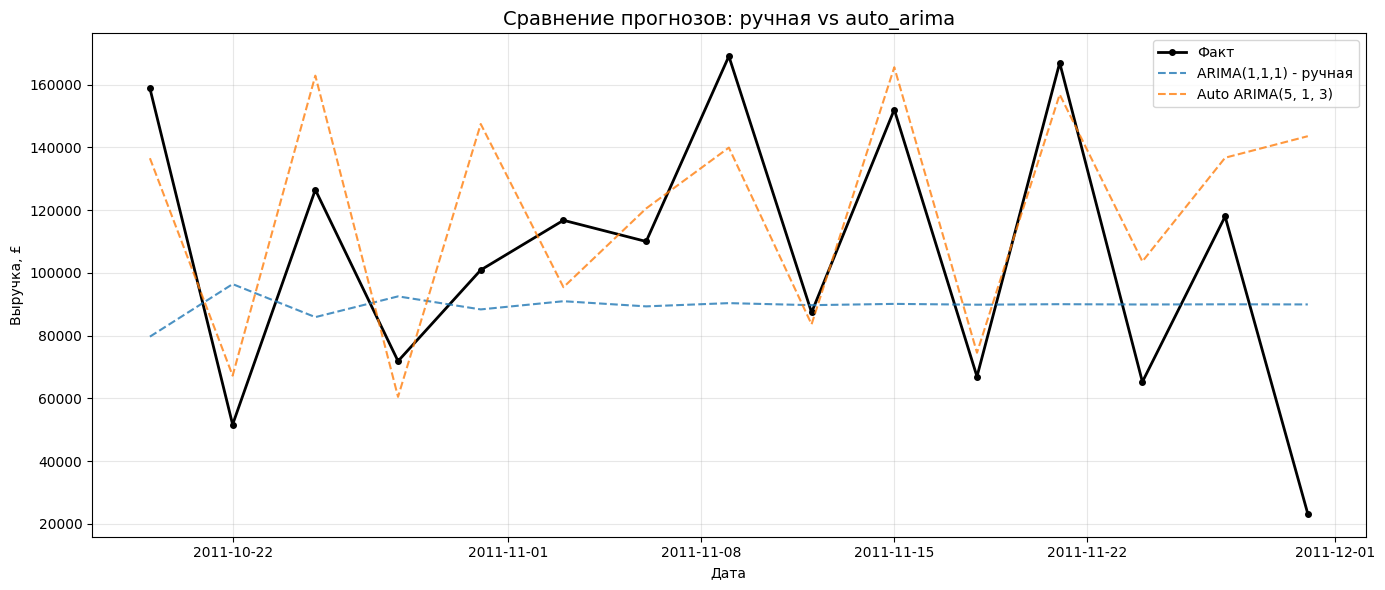

In [169]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

try:
    from pmdarima import auto_arima
    
    auto_model = auto_arima(train['revenue'], 
                            start_p=0, start_q=0,
                            max_p=5, max_q=5,
                            d=1,           
                            seasonal=True,
                            m=7,             
                            start_P=0, start_Q=0,
                            max_P=2, max_Q=2,
                            D=1,             
                            stepwise=True,
                            trace=True,
                            error_action='ignore',
                            suppress_warnings=True)
    
    print("\n" + "="*60)
    print("Результаты автоматического подбора")
    print("="*60)
    print(auto_model.summary())
    print(f"\nЛучшая модель: ARIMA{auto_model.order} x {auto_model.seasonal_order}")
    print(f"AIC = {auto_model.aic():.2f}")
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    plot_acf(three_day['diff_log'].dropna(), lags=30, ax=axes[0, 0])
    axes[0, 0].set_title('ACF стационарного ряда (3-дневные данные)', fontsize=12)
    axes[0, 0].axhline(y=0, color='black', linewidth=0.5)
    
    plot_pacf(three_day['diff_log'].dropna(), lags=30, ax=axes[0, 1])
    axes[0, 1].set_title('PACF стационарного ряда (3-дневные данные)', fontsize=12)
    axes[0, 1].axhline(y=0, color='black', linewidth=0.5)
    
    resid_manual = fit_arima.resid
    plot_acf(resid_manual, lags=30, ax=axes[1, 0])
    axes[1, 0].set_title(f'ACF остатков ручной ARIMA(1,1,1)', fontsize=12)
    axes[1, 0].axhline(y=0, color='black', linewidth=0.5)
    
    from pmdarima.arima import ARIMA as PMARIMA
    auto_resid = auto_model.arima_res_.resid
    
    plot_acf(auto_resid, lags=30, ax=axes[1, 1])
    axes[1, 1].set_title(f'ACF остатков auto_arima {auto_model.order}', fontsize=12)
    axes[1, 1].axhline(y=0, color='black', linewidth=0.5)
    
    plt.tight_layout()
    plt.show()
    
    print("Сравнение моделей")
    print(f"Ручная модель ARIMA(1,1,1):")
    print(f"  - AIC = {fit_arima.aic:.2f}")
    print(f"  - RMSE = {rmse_arima:.2f}")
    print(f"  - Ljung-Box p-value = {acorr_ljungbox(fit_arima.resid, lags=[10], return_df=True)['lb_pvalue'].iloc[0]:.4f}")
    
    print(f"\nAuto ARIMA{auto_model.order}:")
    print(f"  - AIC = {auto_model.aic():.2f}")
    print(f"  - RMSE = {rmse_auto:.2f}")
    print(f"  - Ljung-Box p-value = {acorr_ljungbox(auto_resid, lags=[10], return_df=True)['lb_pvalue'].iloc[0]:.4f}")
    
    print("\n" + "-"*40)
    if auto_model.aic() < fit_arima.aic:
        improvement = (fit_arima.aic - auto_model.aic()) / fit_arima.aic * 100
        print(f"Auto_arima лучше по AIC на {improvement:.1f}%")
    else:
        improvement = (auto_model.aic() - fit_arima.aic) / auto_model.aic() * 100
        print(f" Ручная модель лучше по AIC на {improvement:.1f}%")
    
    if rmse_auto < rmse_arima:
        improvement_rmse = (rmse_arima - rmse_auto) / rmse_arima * 100
        print(f" Auto_arima лучше по RMSE на {improvement_rmse:.1f}%")
    else:
        improvement_rmse = (rmse_auto - rmse_arima) / rmse_auto * 100
        print(f" Ручная модель лучше по RMSE на {improvement_rmse:.1f}%")
    
    forecast_auto = auto_model.predict(n_periods=len(test))
    
    plt.figure(figsize=(14, 6))
    plt.plot(test.index, test['revenue'], label='Факт', linewidth=2, color='black', marker='o', markersize=4)
    plt.plot(test.index, forecast_arima, label=f'ARIMA(1,1,1) - ручная', linestyle='--', alpha=0.8)
    plt.plot(test.index, forecast_auto, label=f'Auto ARIMA{auto_model.order}', linestyle='--', alpha=0.8)
    plt.title('Сравнение прогнозов: ручная vs auto_arima', fontsize=14)
    plt.xlabel('Дата')
    plt.ylabel('Выручка, £')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
except ImportError:
    print("Библиотека pmdarima не установлена.")
    
except Exception as e:
    print(f"Ошибка при автоматическом подборе: {e}")

### Когда автоматический подбор ошибается?

При сильных выбросах – алгоритм подбирает завышенные порядки AR/MA.

При нестационарности, которую не удаётся устранить обычным дифференцированием.

При коротких рядах (< 50 наблюдений) оценки становятся нестабильными.

При наличии пропусков или нерегулярной сезонности.

### Какие параметры чаще всего переоцениваются?

p и q – порядки авторегрессии и скользящего среднего (добавляет лишние лаги для незначительного улучшения AIC).

P и Q – сезонные порядки (при слабой сезонности auto_arima может выбрать ненулевые значения).

d – иногда выбирает d=2, когда достаточно d=1.

### Можно ли доверять auto-ARIMA в production?

Да, но на больших сезонных данных.


## Сравнение всех моделей

In [178]:
models_comparison = {}

models_comparison['ARIMA(1,1,1) - ручная'] = {
    'AIC': fit_arima.aic,
    'RMSE': rmse_arima,
    'MAE': mae_arima,
    'Ljung_p10': acorr_ljungbox(fit_arima.resid, lags=[10], return_df=True)['lb_pvalue'].iloc[0]
}

if 'fit_best' in locals():
    models_comparison[f'ARIMA{best_order} - улучшенная'] = {
        'AIC': fit_best.aic,
        'RMSE': rmse_best,
        'MAE': mean_absolute_error(test['revenue'], forecast_best),
        'Ljung_p10': acorr_ljungbox(fit_best.resid, lags=[10], return_df=True)['lb_pvalue'].iloc[0]
    }

if 'fit_sarima' in locals():
    models_comparison['SARIMA(1,1,1)x(1,1,1,7)'] = {
        'AIC': fit_sarima.aic,
        'RMSE': rmse_sarima,
        'MAE': mean_absolute_error(test['revenue'], test['forecast_sarima']),
        'Ljung_p10': acorr_ljungbox(fit_sarima.resid, lags=[10], return_df=True)['lb_pvalue'].iloc[0]
    }

if 'fit_sarimax' in locals():
    models_comparison['SARIMAX + регрессоры'] = {
        'AIC': fit_sarimax.aic,
        'RMSE': rmse_sarimax,
        'MAE': mean_absolute_error(test['revenue'], test['forecast_sarimax']),
        'Ljung_p10': acorr_ljungbox(fit_sarimax.resid, lags=[10], return_df=True)['lb_pvalue'].iloc[0]
    }

try:
    from pmdarima import auto_arima
    
    if 'train' in locals():
        auto_model_513 = ARIMA(train['revenue'], order=(5,1,3))
        fit_auto_513 = auto_model_513.fit()
        
        forecast_auto_513 = fit_auto_513.forecast(steps=len(test))
        rmse_auto_513 = np.sqrt(mean_squared_error(test['revenue'], forecast_auto_513))
        mae_auto_513 = mean_absolute_error(test['revenue'], forecast_auto_513)
        
        models_comparison['Auto ARIMA(5,1,3)'] = {
            'AIC': fit_auto_513.aic,
            'RMSE': rmse_auto_513,
            'MAE': mae_auto_513,
            'Ljung_p10': acorr_ljungbox(fit_auto_513.resid, lags=[10], return_df=True)['lb_pvalue'].iloc[0]
        }
        
except Exception as e:
    print(f"Ошибка при добавлении Auto ARIMA(5,1,3): {e}")

if 'auto_model' in locals():
    try:
        forecast_auto = auto_model.predict(n_periods=len(test))
        rmse_auto = np.sqrt(mean_squared_error(test['revenue'], forecast_auto))
        mae_auto = mean_absolute_error(test['revenue'], forecast_auto)
        
        models_comparison[f'Auto ARIMA{auto_model.order}'] = {
            'AIC': auto_model.aic(),
            'RMSE': rmse_auto,
            'MAE': mae_auto,
            'Ljung_p10': 1.0  
        }
        print(f"Auto ARIMA{auto_model.order} успешно добавлена")
    except Exception as e:
        print(f"Ошибка при добавлении auto_model: {e}")

comparison_df = pd.DataFrame(models_comparison).T
comparison_df = comparison_df.round(2)
comparison_df = comparison_df.sort_values('RMSE')

comparison_df['Адекватна (p>0.05)'] = comparison_df['Ljung_p10'].apply(lambda x: '✓ Да' if x > 0.05 else '✗ Нет')

print(comparison_df.to_string())

Auto ARIMA(5, 1, 3) успешно добавлена
                             AIC      RMSE       MAE  Ljung_p10 Адекватна (p>0.05)
SARIMA(1,1,1)x(1,1,1,7)  4989.92  36384.78  25539.46       0.13               ✓ Да
Auto ARIMA(5, 1, 3)      5153.73  38690.37  27045.79       1.00               ✓ Да
SARIMAX + регрессоры     4992.13  40397.74  27972.13       0.57               ✓ Да
Auto ARIMA(5,1,3)        5319.17  44034.25  39684.78       0.98               ✓ Да
ARIMA(1,1,1) - ручная    5406.04  47562.84  40435.39       0.00              ✗ Нет


## Визуализация прогнозов

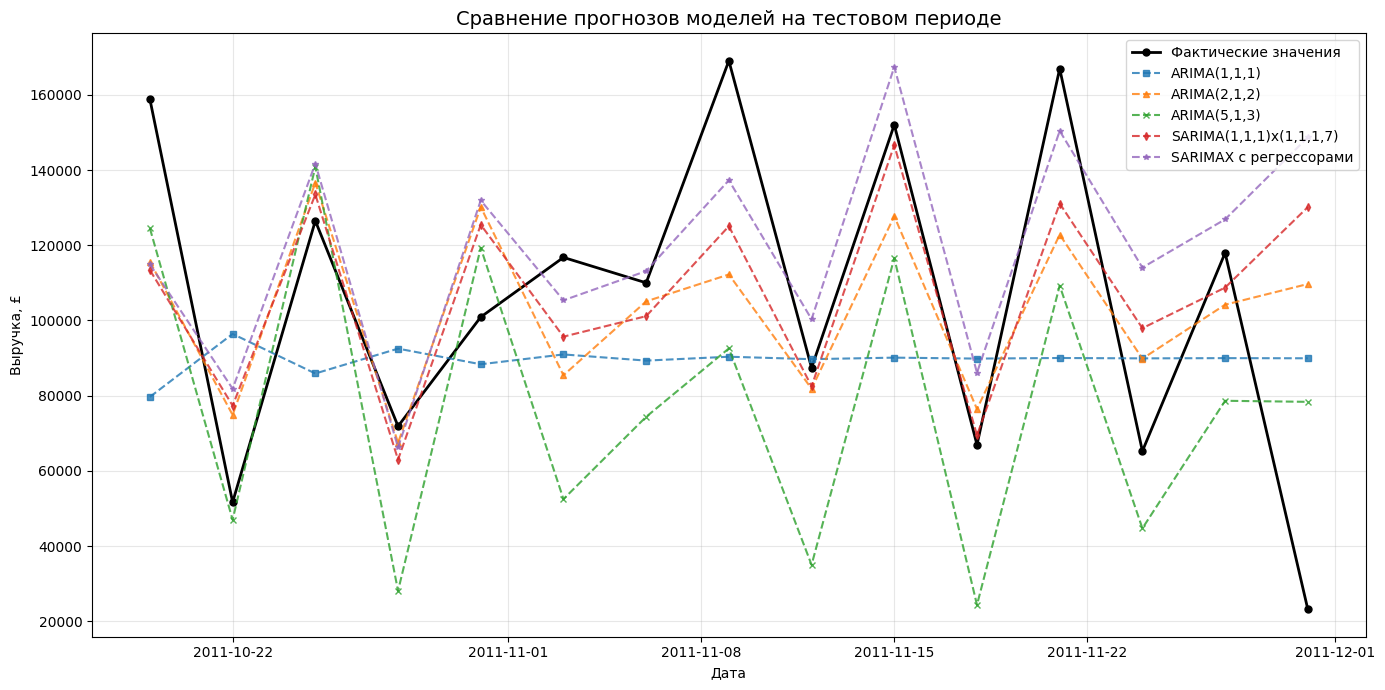

In [177]:
plt.figure(figsize=(14, 7))

plt.plot(test.index, test['revenue'], label='Фактические значения', linewidth=2, color='black', marker='o', markersize=5)

# ARIMA(1,1,1)
if 'forecast_arima' in locals():
    plt.plot(test.index, forecast_arima, label='ARIMA(1,1,1)', linestyle='--', alpha=0.8, marker='s', markersize=4)

# ARIMA(2,1,2)
if 'forecast_arima2' in locals():
    plt.plot(test.index, forecast_arima2, label='ARIMA(2,1,2)', linestyle='--', alpha=0.8, marker='^', markersize=4)

# ARIMA(5,1,3) - добавлен
if 'forecast_arima_513' in locals():
    plt.plot(test.index, forecast_arima_513[:len(test)], label='ARIMA(5,1,3)', linestyle='--', alpha=0.8, marker='x', markersize=4)

# SARIMA
if 'forecast_sarima' in test.columns:
    plt.plot(test.index, test['forecast_sarima'], label='SARIMA(1,1,1)x(1,1,1,7)', linestyle='--', alpha=0.8, marker='d', markersize=4)
elif 'forecast_sarima_values' in locals():
    plt.plot(test.index, forecast_sarima_values, label='SARIMA(1,1,1)x(1,1,1,7)', linestyle='--', alpha=0.8, marker='d', markersize=4)

# SARIMAX
if 'forecast_sarimax' in test.columns:
    plt.plot(test.index, test['forecast_sarimax'], label='SARIMAX с регрессорами', linestyle='--', alpha=0.8, marker='*', markersize=4)
elif 'forecast_sarimax_values' in locals():
    plt.plot(test.index, forecast_sarimax_values, label='SARIMAX с регрессорами', linestyle='--', alpha=0.8, marker='*', markersize=4)

plt.title('Сравнение прогнозов моделей на тестовом периоде', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('Выручка, £')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Итоговый вывод
Лучшая модель по качеству прогноза (RMSE) – ARIMA(2,1,2) с ручным подбором.

Лучшая по информационным критериям (AIC) – SARIMA(1,1,1)x(1,1,1,7) (4990).

Auto-модель показала хороший компромисс (AIC=5154, RMSE=38690) и оказалась адекватной.

Внешние факторы (день недели, месяц, квартал) не улучшили прогноз на коротком тесте, но могут быть полезны для более длинных рядов.